In [106]:
import geopandas as gpd
import numpy as np
import pandas as pd

# Imports
import time
from sliderule import sliderule, icesat2, raster

In [ ]:
sierras = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

In [157]:
def download_icesat2(region, start_date, end_date):

    # Initialization
    #sliderule.init("sliderule-blue", verbose=True)
    icesat2.init("slideruleearth.io", verbose=True)

    # Parameters
    parms = {
        "poly": region,
        "srt": icesat2.SRT_LAND,
        "cnf": icesat2.CNF_SURFACE_HIGH,
        "atl08_class": "atl08_ground",
        "ats": 10.0,
        "cnt": 10,
        "len": 40.0,
        "res": 20.0,
        "fit": {"maxi": 10},
        "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
        "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "slope_aspect":True, "force_single_sample":True}},
        't0': start_date,
        't1': end_date
    }

    # Latch Start Time
    perf_start = time.perf_counter()

    # Request ATL06 Data
    gdf = sliderule.run("atl03x", parms) #, resources=["ATL03_20210309052953_11491002_006_01.h5"])

    # Latch Stop Time
    perf_stop = time.perf_counter()

    # Display Statistics
    perf_duration = perf_stop - perf_start
    print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
    print("Reference Ground Tracks: {}".format(gdf["rgt"].unique()))
    print("Cycles: {}".format(gdf["cycle"].unique()))
    print("Received {} elevations".format(gdf.shape[0]))

    return gdf

In [173]:
def download_slope_aspect(gdf):

    coordinates = [[pt.x, pt.y] for pt in gdf.to_crs('epsg:4326').geometry]
    sa_gdf = raster.sample("usgs3dep-10meter-dem", coordinates, {"slope_aspect": True})
    joined_gdf = gpd.sjoin(gdf.to_crs('epsg:4326'), sa_gdf, how='left', predicate='intersects')
    
    return joined_gdf

### South Region for 2020 - 2021:

In [ ]:
# Area of Interest
south_region = [
    {"lon": -120.2, "lat": 34.818611},
    {"lon": -117.862654, "lat": 34.818611},
    {"lon": -117.862654, "lat": 37.5},
    {"lon": -120.2, "lat": 37.5},
    {"lon": -120.2, "lat": 34.818611}
]

In [235]:
south_sierras_2021 = download_icesat2(south_region, '2020-09-30T08:00:00Z', '2021-09-30T08:00:00Z')

Completed in 259.055 seconds of wall-clock time
Reference Ground Tracks: [ 242  684  265  707  181 1088 1065  120 1126  143  623   59  562  646
  326 1210  501 1271 1149  585  204 1004  768]
Cycles: [ 9 11 12 10 13]
Received 2450753 elevations


In [236]:
south_sierras_2021_clip = south_sierras_2021.clip(sierras.to_crs(south_sierras_2021.crs))

In [237]:
south_sierras_2021_clip_sa = download_slope_aspect(south_sierras_2021_clip)

In [172]:
south_sierras_clip_sa

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,segment_landcover,cycle,photon_start,geometry,time,slope_count,slope,aspect,file,value
time_ns,,,,,,,,,,,,,,,,,,,,,
2021-09-30 07:56:00.926019328,0.0,1.0,0,226.925572,6,12.837279,50,12,3.334748,68719476736,...,30.0,13,1315620,POINT (-118.94867 36.18458),2022-12-03 18:59:21,9,12.837279,323.583631,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,226.925572
2021-09-30 07:56:00.889512704,0.0,1.0,0,234.648513,6,19.617888,50,12,3.000000,68719476736,...,30.0,13,1315550,POINT (-118.94839 36.18691),2022-12-03 18:59:21,9,19.617888,3.422362,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,234.648513
2021-09-30 07:56:00.866955008,0.0,1.0,0,234.618257,6,12.795578,50,11,3.000000,68719476736,...,30.0,13,1315509,POINT (-118.94821 36.18834),2022-12-03 18:59:21,9,12.795578,348.577549,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,234.618257
2020-12-08 09:52:24.436292352,0.0,1.0,0,255.981556,2,22.209101,30,31,8.577431,51539607552,...,40.0,9,1386909,POINT (-118.97406 36.20437),2022-12-03 18:59:21,9,22.209101,235.247265,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,255.981556
2020-12-08 09:52:24.439094272,0.0,1.0,0,262.810031,2,21.143680,30,28,7.474855,51539607552,...,40.0,9,1386965,POINT (-118.97408 36.20455),2022-12-03 18:59:21,9,21.143680,240.097325,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,262.810031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-30 10:51:51.743332608,0.0,1.0,0,1441.092804,6,4.961883,50,14,3.000000,133143986176,...,20.0,12,611050,POINT (-118.44029 37.31995),2022-12-03 18:59:21,9,4.961883,20.048587,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1441.092805
2021-07-30 10:51:52.071341824,0.0,1.0,0,1442.709804,6,5.333149,60,56,3.000000,133143986176,...,20.0,12,2562796,POINT (-118.44116 37.32075),2022-12-03 18:59:21,9,5.333149,51.171980,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1442.709804
2021-07-30 10:51:52.068510208,0.0,1.0,0,1441.791623,6,5.288756,60,14,5.024507,133143986176,...,20.0,12,2562796,POINT (-118.44114 37.32093),2022-12-03 18:59:21,9,5.288756,43.697853,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1441.791624


### South Region for 2019 - 2020:

In [238]:
south_sierras_2020 = download_icesat2(south_region, '2019-09-30T08:00:00Z', '2020-09-30T08:00:00Z')

Completed in 277.796 seconds of wall-clock time
Reference Ground Tracks: [ 181  562 1004  326 1088  204 1126  585  623  265 1149  684  768  143
   59  120  501  646 1065 1210  707  242]
Cycles: [8 6 7 5 9]
Received 2536363 elevations


In [239]:
south_sierras_2020_clip = south_sierras_2020.clip(sierras.to_crs(south_sierras_2020.crs))

In [240]:
south_sierras_2020_clip_sa = download_slope_aspect(south_sierras_2020_clip)

### South Region for 2018 - 2019:

In [241]:
south_sierras_2019 = download_icesat2(south_region, '2018-09-30T08:00:00Z', '2019-09-30T08:00:00Z')

Completed in 263.951 seconds of wall-clock time
Reference Ground Tracks: [ 326  562  707   59  501  181  684  204  120  265  623 1088 1210 1149
 1065 1126  585 1004  143  646  242  768]
Cycles: [1 2 3 4]
Received 2160703 elevations


In [242]:
south_sierras_2019_test3 = download_icesat2(south_region, '2018-09-30T00:00:00Z', '2019-09-30T00:00:00Z')

KeyboardInterrupt: 

In [232]:
south_sierras_2019_test4 = download_icesat2(south_region, '2018-09-30T00:00:00Z', '2019-10-13T00:00:00Z')

Completed in 262.205 seconds of wall-clock time
Reference Ground Tracks: [1065  501 1126  684 1210 1149 1004  562  646  242  768  623   59  181
  143  204  326  707  120  585 1088  265]
Cycles: [2 4 1 3 5]
Received 2292561 elevations


In [224]:
south_sierras_2019

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,spot,y_atc,urban_flag,3dep.time_ns,beam_azimuth,srcid,segment_landcover,cycle,photon_start,geometry
time_ns,,,,,,,,,,,,,,,,,,,,,
2019-01-18 18:53:09.559323648,0.0,1.0,0,394.860651,2,0.476550,20,31,3.0,12884901888,...,2,3357.691650,0.0,2022-12-03 18:59:03,1.510548,14,30.0,2,1329229,POINT (-120.17298 35.4346)
2019-01-18 18:53:09.562131200,0.0,1.0,0,394.781755,2,0.524962,20,29,3.0,12884901888,...,2,3357.742920,0.0,2022-12-03 18:59:03,1.510548,14,30.0,2,1329392,POINT (-120.17301 35.43478)
2019-01-18 18:53:09.564935936,0.0,1.0,0,394.742501,2,0.468032,20,28,3.0,12884901888,...,2,3357.774414,0.0,2022-12-03 18:59:03,1.510548,14,30.0,2,1329548,POINT (-120.17303 35.43496)
2019-01-18 18:53:09.567740928,0.0,1.0,0,394.689544,2,0.159082,20,14,3.0,12884901888,...,2,3357.797363,0.0,2022-12-03 18:59:03,1.510548,14,30.0,2,1329683,POINT (-120.17305 35.43514)
2019-01-18 18:53:09.978242304,0.0,1.0,0,386.061530,2,0.062160,20,23,3.0,12884901888,...,2,3357.411377,0.0,2022-12-03 18:59:03,1.510607,14,30.0,2,1358372,POINT (-120.17614 35.46134)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-05-18 13:09:35.223802880,0.0,1.0,0,302.161535,2,23.773134,20,32,3.0,313532612608,...,2,3167.523926,0.0,2022-12-03 18:59:03,1.411822,461,126.0,3,550842,POINT (-120.15737 37.49189)
2019-05-18 13:09:35.226629888,0.0,1.0,0,299.242457,2,3.186710,20,46,3.0,313532612608,...,2,3167.452148,0.0,2022-12-03 18:59:03,1.411780,461,126.0,3,550842,POINT (-120.15739 37.49206)
2019-05-18 13:09:35.229464064,0.0,1.0,0,300.811079,2,5.452003,20,14,3.0,313532612608,...,2,3167.387451,0.0,2022-12-03 18:59:03,1.411684,461,126.0,3,550879,POINT (-120.15741 37.49224)


In [222]:
south_sierras_2019

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,spot,y_atc,urban_flag,3dep.time_ns,beam_azimuth,srcid,segment_landcover,cycle,photon_start,geometry
time_ns,,,,,,,,,,,,,,,,,,,,,
2019-04-10 03:09:10.978445824,0.0,2.0,0,2145.840887,6,20.407028,20,34,8.418311,64424509440,...,2,3128.016113,0.0,2022-12-03 18:59:03,-1.545165,6,111.000000,3,1386662,POINT (-119.38568 37.49982)
2019-04-10 03:09:10.981258752,0.0,2.0,0,2139.225737,6,19.073625,20,28,6.949850,64424509440,...,2,3128.155762,0.0,2022-12-03 18:59:03,-1.545165,6,111.000000,3,1386715,POINT (-119.3857 37.49964)
2019-04-10 03:09:10.984071936,0.0,2.0,0,2132.215812,6,21.542237,20,22,7.041969,64424509440,...,2,3128.287842,0.0,2022-12-03 18:59:03,-1.545164,6,111.909091,3,1386771,POINT (-119.38572 37.49946)
2019-04-10 03:09:10.986884608,0.0,2.0,0,2125.733231,6,12.749218,20,35,13.423816,64424509440,...,2,3128.391357,0.0,2022-12-03 18:59:03,-1.545162,6,119.000000,3,1386828,POINT (-119.38574 37.49928)
2019-04-10 03:09:10.989696768,0.0,2.0,0,2133.678870,6,36.915683,20,32,10.808957,64424509440,...,2,3128.410645,0.0,2022-12-03 18:59:03,-1.545162,6,121.000000,3,1386859,POINT (-119.38576 37.4991)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-02-11 05:57:23.301020672,0.0,1.0,0,21.213903,6,0.694954,50,69,3.000000,339302416384,...,5,395.277069,0.0,2022-12-03 18:59:03,-0.227895,485,40.000000,2,14672198,POINT (-120.05382 36.51641)
2019-02-11 05:57:23.303842560,0.0,1.0,0,21.264814,6,0.498124,50,52,3.000000,339302416384,...,5,395.334045,0.0,2022-12-03 18:59:03,-0.227895,485,40.000000,2,14672239,POINT (-120.05384 36.51623)
2019-02-11 05:57:23.306663680,0.0,1.0,0,21.437738,6,0.479963,50,59,3.000000,339302416384,...,5,395.391937,0.0,2022-12-03 18:59:03,-0.227895,485,40.000000,2,14672282,POINT (-120.05386 36.51605)


In [225]:
2160703 - 2291681

-130978

In [227]:
south_sierras_2019_clip_1 = south_sierras_2019.clip(sierras.to_crs(south_sierras_2019.crs))

In [230]:
south_sierras_2019_clip_2 = south_sierras_2019_test3.clip(sierras.to_crs(south_sierras_2019_test3.crs))

<Axes: >

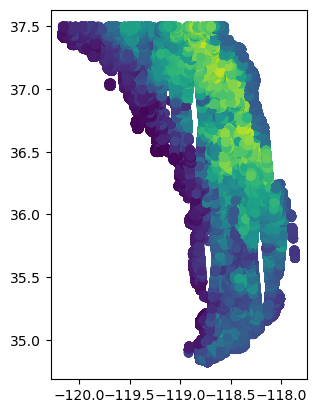

In [231]:
south_sierras_2019_clip_2.plot(column='h_mean')

<Axes: >

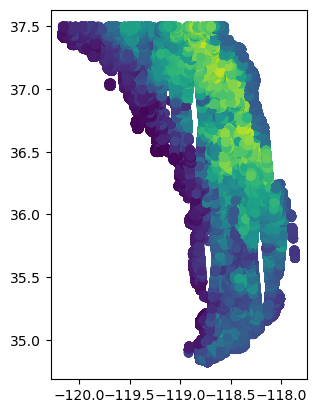

In [228]:
south_sierras_2019_clip_1.plot(column='h_mean')

<Axes: >

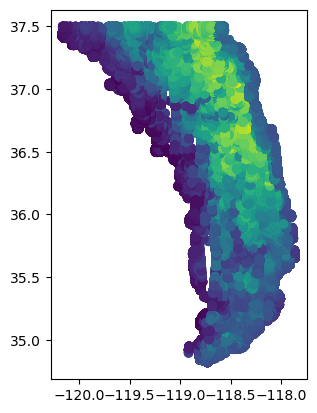

In [226]:
south_sierras_2019_clip.plot(column='h_mean')

In [243]:
south_sierras_2019_clip = south_sierras_2019.clip(sierras.to_crs(south_sierras_2019.crs))

In [244]:
south_sierras_2019_clip_sa = download_slope_aspect(south_sierras_2019_clip)

### North region #1 2020 - 2021

In [245]:
# Area of Interest
north_region_1 = [  {"lon": -121.1, "lat": 37.5},
            {"lon": -118.5, "lat": 37.5},
            {"lon": -118.5, "lat": 39},
            {"lon": -121.1, "lat": 39},
            {"lon": -121.1, "lat": 37.5}  ]

In [246]:
north_sierras_1_2021 = download_icesat2(north_region_1, '2020-09-30T08:00:00Z', '2021-09-30T08:00:00Z')

Completed in 274.517 seconds of wall-clock time
Reference Ground Tracks: [ 181  684  768  646  265 1271  204  326 1187 1088  303 1210  623 1149
 1126 1248  707  829  387  745  120  242 1065]
Cycles: [12 11  9 10 13]
Received 1363494 elevations


In [247]:
north_sierras_1_2021_clip = north_sierras_1_2021.clip(sierras.to_crs(north_sierras_1_2021.crs))

In [248]:
north_sierras_1_2021_clip_sa = download_slope_aspect(north_sierras_1_2021_clip)

### North region #1 2019 - 2020

In [249]:
north_sierras_1_2020 = download_icesat2(north_region_1, '2019-09-30T08:00:00Z', '2020-09-30T08:00:00Z')

Completed in 214.140 seconds of wall-clock time
Reference Ground Tracks: [ 829  684  768  242  623 1065 1126  204  303  181  646  120  326 1187
 1210  387 1149 1248  265 1271  707  745]
Cycles: [7 6 8 5]
Received 1203584 elevations


In [250]:
north_sierras_1_2020_clip = north_sierras_1_2020.clip(sierras.to_crs(north_sierras_1_2020.crs))

In [251]:
north_sierras_1_2020_clip_sa = download_slope_aspect(north_sierras_1_2020_clip)

### North region #1 2018 - 2019

In [252]:
north_sierras_1_2019 = download_icesat2(north_region_1, '2018-09-30T08:00:00Z', '2019-09-30T08:00:00Z')

Completed in 219.207 seconds of wall-clock time
Reference Ground Tracks: [1065  768  120  326  684 1271  707  181  242 1248 1187  265  646  623
 1126 1149  829  745 1088  204  562 1210  387  303]
Cycles: [2 1 3 4]
Received 1052910 elevations


In [253]:
north_sierras_1_2019_clip = north_sierras_1_2019.clip(sierras.to_crs(north_sierras_1_2019.crs))

In [254]:
north_sierras_1_2019_clip_sa = download_slope_aspect(north_sierras_1_2019_clip)

### North region #2 2020 - 2021

In [255]:
# Area of Interest
north_region_2 = [  {"lon": -121.948903, "lat": 39},
            {"lon": -119.75, "lat": 39},
            {"lon": -119.75, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 39}  ]

In [256]:
north_sierras_2_2021 = download_icesat2(north_region_2, '2020-09-30T08:00:00Z', '2021-09-30T08:00:00Z')

Completed in 221.166 seconds of wall-clock time
Reference Ground Tracks: [ 806  303 1187  745 1248  326  768 1332  867 1210  684  364 1309  387
  265  890  707 1271  242  829]
Cycles: [ 9 11 12 10]
Received 942031 elevations


In [257]:
north_sierras_2_2021_clip = north_sierras_2_2021.clip(sierras.to_crs(north_sierras_2_2021.crs))

In [258]:
north_sierras_2_2021_clip_sa = download_slope_aspect(north_sierras_2_2021_clip)

### North region #2 2019 - 2020

In [259]:
north_sierras_2_2020 = download_icesat2(north_region_2, '2019-09-30T08:00:00Z', '2020-09-30T08:00:00Z')

Completed in 205.254 seconds of wall-clock time
Reference Ground Tracks: [ 684  387  242  707  745  303  829  265 1187 1332  806  326  890 1309
  867  364 1271 1248  768 1210]
Cycles: [6 5 8 7]
Received 913272 elevations


In [260]:
north_sierras_2_2020_clip = north_sierras_2_2020.clip(sierras.to_crs(north_sierras_2_2020.crs))

In [261]:
north_sierras_2_2020_clip_sa = download_slope_aspect(north_sierras_2_2020_clip)

### North region #2 2018 - 2019

In [262]:
north_sierras_2_2019 = download_icesat2(north_region_2, '2018-09-30T08:00:00Z', '2019-09-30T08:00:00Z')

Completed in 191.054 seconds of wall-clock time
Reference Ground Tracks: [ 364  242  745  707 1309  265  387  829  326  303  806  890 1187 1271
  684  768 1210 1248  867 1332]
Cycles: [2 4 1 3]
Received 846712 elevations


In [263]:
north_sierras_2_2019_clip = north_sierras_2_2019.clip(sierras.to_crs(north_sierras_2_2019.crs))

In [264]:
north_sierras_2_2019_clip_sa = download_slope_aspect(north_sierras_2_2019_clip)

### Combine all joined dataframes to have the entire Sierras ICESat-2 data for 2018-2021 with slope:

In [193]:
south_sierras_clip_sa = south_sierras_clip_sa.to_crs('epsg:4326')

In [269]:
sierras_2018_2021_sa = pd.concat([south_sierras_2019_clip_sa, 
                                  south_sierras_2020_clip_sa,
                                  south_sierras_2021_clip_sa,
                                  north_sierras_1_2019_clip_sa,
                                  north_sierras_1_2020_clip_sa,
                                  north_sierras_1_2021_clip_sa,
                                  north_sierras_2_2019_clip_sa,
                                  north_sierras_2_2020_clip_sa,
                                  north_sierras_2_2021_clip_sa])

In [270]:
sierras_2018_2021_sa['time_acq'] = sierras_2018_2021_sa.index

In [271]:
sierras_2018_2021_sa = sierras_2018_2021_sa.sort_values(by='time_acq',ascending=True)

In [272]:
sierras_2018_2021_sa

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,cycle,photon_start,geometry,time,slope_count,slope,aspect,file,value,time_acq
time_ns,,,,,,,,,,,,,,,,,,,,,
2018-10-14 11:40:32.487777792,0.0,1.0,0,1519.017723,6,3.702048,50,28,3.0,158913789952,...,1,2730912,POINT (-119.96541 39.64595),2022-12-03 18:59:21,9,3.702048,71.460119,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1519.017727,2018-10-14 11:40:32.487777792
2018-10-14 11:40:32.490599168,0.0,1.0,0,1518.552710,6,3.227038,50,37,3.0,158913789952,...,1,2730940,POINT (-119.96543 39.64577),2022-12-03 18:59:21,9,3.227038,233.839977,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.552714,2018-10-14 11:40:32.490599168
2018-10-14 11:40:32.493418752,0.0,1.0,0,1518.741140,6,2.125614,50,44,3.0,158913789952,...,1,2730960,POINT (-119.96545 39.6456),2022-12-03 18:59:21,9,2.125614,78.941620,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.741144,2018-10-14 11:40:32.493418752
2018-10-14 11:40:32.496237568,0.0,1.0,0,1518.743413,6,1.243358,50,41,3.0,158913789952,...,1,2730989,POINT (-119.96548 39.64542),2022-12-03 18:59:21,9,1.027569,229.168357,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.894784,2018-10-14 11:40:32.496237568
2018-10-14 11:40:32.499053056,0.0,1.0,0,1518.892049,6,0.707748,50,32,3.0,158913789952,...,1,2731010,POINT (-119.9655 39.64524),2022-12-03 18:59:21,9,0.707748,129.684072,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.892053,2018-10-14 11:40:32.499053056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 07:56:05.208622336,0.0,1.0,0,284.338497,6,1.941521,20,34,3.0,94489280512,...,13,5778111,POINT (-118.90845 35.92973),2022-12-03 18:59:21,9,1.941521,305.870117,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,284.338555,2021-09-30 07:56:05.208622336
2021-09-30 07:56:05.211433728,0.0,1.0,0,283.677498,6,2.244505,20,27,3.0,94489280512,...,13,5778134,POINT (-118.90847 35.92955),2022-12-03 18:59:21,9,2.244505,293.216634,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,283.677556,2021-09-30 07:56:05.211433728
2021-09-30 07:56:05.214239488,0.0,1.0,0,282.900288,6,2.365801,20,26,3.0,94489280512,...,13,5778147,POINT (-118.9085 35.92938),2022-12-03 18:59:21,9,2.365801,283.413983,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,282.900346,2021-09-30 07:56:05.214239488


In [198]:
#sierras_2018_2021_sa = sierras_2018_2021_sa['2018-09-30 08:00:00.000000000':'2021-10-01 08:00:00.000000000']

In [207]:
sierras_2018_2021_sa

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,cycle,photon_start,geometry,time,slope_count,slope,aspect,file,value,time_acq
time_ns,,,,,,,,,,,,,,,,,,,,,
2018-10-14 11:40:32.487777792,0.0,1.0,0,1519.017723,6,3.702048,50,28,3.0,249108103168,...,1,2730912,POINT (-119.96541 39.64595),2022-12-03 18:59:21,9,3.702048,71.460119,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1519.017727,2018-10-14 11:40:32.487777792
2018-10-14 11:40:32.490599168,0.0,1.0,0,1518.552710,6,3.227038,50,37,3.0,249108103168,...,1,2730940,POINT (-119.96543 39.64577),2022-12-03 18:59:21,9,3.227038,233.839977,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.552714,2018-10-14 11:40:32.490599168
2018-10-14 11:40:32.493418752,0.0,1.0,0,1518.741140,6,2.125614,50,44,3.0,249108103168,...,1,2730960,POINT (-119.96545 39.6456),2022-12-03 18:59:21,9,2.125614,78.941620,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.741144,2018-10-14 11:40:32.493418752
2018-10-14 11:40:32.496237568,0.0,1.0,0,1518.743413,6,1.243358,50,41,3.0,249108103168,...,1,2730989,POINT (-119.96548 39.64542),2022-12-03 18:59:21,9,1.027569,229.168357,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.894784,2018-10-14 11:40:32.496237568
2018-10-14 11:40:32.499053056,0.0,1.0,0,1518.892049,6,0.707748,50,32,3.0,249108103168,...,1,2731010,POINT (-119.9655 39.64524),2022-12-03 18:59:21,9,0.707748,129.684072,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,1518.892053,2018-10-14 11:40:32.499053056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 07:56:05.208622336,0.0,1.0,0,284.338497,6,1.941521,20,34,3.0,68719476736,...,13,5778111,POINT (-118.90845 35.92973),2022-12-03 18:59:21,9,1.941521,305.870118,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,284.338497,2021-09-30 07:56:05.208622336
2021-09-30 07:56:05.211433728,0.0,1.0,0,283.677498,6,2.244505,20,27,3.0,68719476736,...,13,5778134,POINT (-118.90847 35.92955),2022-12-03 18:59:21,9,2.244505,293.216635,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,283.677498,2021-09-30 07:56:05.211433728
2021-09-30 07:56:05.214239488,0.0,1.0,0,282.900288,6,2.365801,20,26,3.0,68719476736,...,13,5778147,POINT (-118.9085 35.92938),2022-12-03 18:59:21,9,2.365801,283.413984,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,282.900288,2021-09-30 07:56:05.214239488


In [274]:
sierras_2018_2021_sa.to_pickle('../data/icesat2/sierras_gdf_2018_2021_sa.pkl')

In [273]:
4672860 - 4670875

1985

### Compare to original tuolumne data:

In [124]:
tuol = gpd.read_file('../data/misc/UpperTuolRiverBasinOutline.geojson')

In [205]:
tuol_atl06sr_downloaded1 = sierras_2018_2021_sa.clip(tuol.to_crs(sierras_2018_2021_sa.crs))

In [208]:
tuol_atl06sr_downloaded1 = tuol_atl06sr_downloaded1.sort_values(by='time_acq',ascending=True)

In [211]:
tuol_atl06sr_downloaded1

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,cycle,photon_start,geometry,time,slope_count,slope,aspect,file,value,time_acq
time_ns,,,,,,,,,,,,,,,,,,,,,
2018-10-15 23:22:20.019409920,0.0,1.0,0,2501.126777,2,1.425569,30,18,3.000000,17179869184,...,1,2326524,POINT (-119.6234 37.8888),2022-12-03 18:59:21,9,1.425569,64.727571,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2501.126855,2018-10-15 23:22:20.019409920
2018-10-15 23:22:20.022249216,0.0,1.0,0,2500.715515,2,0.682238,30,13,3.000000,17179869184,...,1,2326621,POINT (-119.62342 37.88898),2022-12-03 18:59:21,9,1.195349,71.628306,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2500.870867,2018-10-15 23:22:20.022249216
2018-10-15 23:22:20.027903232,0.0,1.0,0,2501.042893,2,1.842238,30,10,3.000000,17179869184,...,1,2326885,POINT (-119.62347 37.88934),2022-12-03 18:59:21,9,1.842238,329.563512,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2501.042972,2018-10-15 23:22:20.027903232
2018-10-15 23:22:20.030719744,0.0,1.0,0,2501.203651,2,2.417284,30,14,3.000000,17179869184,...,1,2327010,POINT (-119.62349 37.88952),2022-12-03 18:59:21,9,2.417284,359.078175,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2501.203730,2018-10-15 23:22:20.030719744
2018-10-15 23:22:20.033533696,0.0,1.0,0,2501.230133,2,2.212113,30,13,3.000000,17179869184,...,1,2327181,POINT (-119.62351 37.8897),2022-12-03 18:59:21,9,2.212113,355.821620,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2501.230212,2018-10-15 23:22:20.033533696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-05 09:11:10.169992448,0.0,1.0,0,2754.451159,6,22.679931,20,23,9.476954,184683593728,...,12,3400198,POINT (-119.59773 37.88864),2022-12-03 18:59:21,9,22.679930,116.067743,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2754.451218,2021-09-05 09:11:10.169992448
2021-09-05 09:11:10.172794112,0.0,1.0,0,2760.357317,6,15.250315,20,39,5.295462,184683593728,...,12,3400251,POINT (-119.59775 37.88846),2022-12-03 18:59:21,9,15.250315,119.529782,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2760.357376,2021-09-05 09:11:10.172794112
2021-09-05 09:11:10.175595264,0.0,1.0,0,2764.738330,6,12.386346,20,42,3.974411,184683593728,...,12,3400281,POINT (-119.59777 37.88828),2022-12-03 18:59:21,9,12.386346,123.662841,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2764.738389,2021-09-05 09:11:10.175595264


<Axes: >

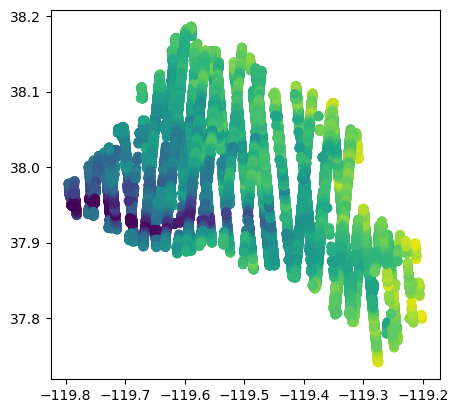

In [212]:
tuol_atl06sr_downloaded1['2020-10-01 00:00:00.000000000':'2021-10-01 00:00:00.000000000'].plot(column='h_mean')

In [215]:
tuol_atl06sr_downloaded1['2020-10-01 00:00:00.000000000':'2021-10-01 00:00:00.000000000'].shape

(47317, 35)

### check by just downloading tuolumne:

In [216]:
# Initialization
#sliderule.init("sliderule-blue", verbose=True)
icesat2.init("slideruleearth.io", verbose=True)

# Area of Interest
# define tuolumne bounding box:
region = [  {"lon": -119.8, "lat": 37.7},
            {"lon": -119.2, "lat": 37.7},
            {"lon": -119.2, "lat": 38.2},
            {"lon": -119.8, "lat": 38.2},
            {"lon": -119.8, "lat": 37.7}  ]

# Parameters
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    #"beams": "gt1l",
    "fit": {"maxi": 10},
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "slope_aspect":True, "force_single_sample":True}},
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z',
}

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
tuolumne_gdf = sliderule.run("atl03x", parms) #, resources=["ATL03_20210309052953_11491002_006_01.h5"])

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(tuolumne_gdf["rgt"].unique()))
print("Cycles: {}".format(tuolumne_gdf["cycle"].unique()))
print("Received {} elevations".format(tuolumne_gdf.shape[0]))

Completed in 69.353 seconds of wall-clock time
Reference Ground Tracks: [ 265 1149  684  181  707 1126  623 1210]
Cycles: [13 12  9 11 10]
Received 113919 elevations


In [217]:
tuolumne_gdf_clipped = tuolumne_gdf.clip(tuol.to_crs(tuolumne_gdf.crs))

In [218]:
len(tuolumne_gdf_clipped['h_mean'])

46592

In [24]:
len(sierras_gdf.geometry) - len(sierras_gdf.geometry.unique())

0

In [25]:
len(sierras_gdf.geometry)

1176461

Simple paper: subsetting by slope in the Sierra yields accurate snow depth values  (short format, 4 pg paper? could even go high profile, submit to nature?) - submit this quarter. Add SlideRule people as coauthors. ex: GRL, nature science papers, nature data? 

- make code accessible  
- talk about 3dep program
- 4 figures (or 3 plus table)